In [1]:
import pandas as pd
import numpy as np

from keras.utils import image_dataset_from_directory
import tensorflow as tf

# Importation pour utiliser un modèle pre entrainé
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.neighbors import NearestNeighbors

from pathlib import Path

import matplotlib.pyplot as plt
import cv2

In [2]:
chemin="/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE"

dataset=image_dataset_from_directory (chemin,
                                      image_size=(224, 224),
                                      batch_size = 32,
                                      shuffle=False,
                                      color_mode='rgb')

Found 20835 files belonging to 4 classes.


2026-08-02 10:05:02.245008: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-08-02 10:05:02.245143: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-02 10:05:02.245147: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1785657902.245368   38930 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1785657902.245657   38930 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
process_ds=dataset.map(lambda x,y: (preprocess_input(x),y))

In [4]:
#Choix du device
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


On charge ici le modèle EfficientNet et on gèle toutes les couches. L'argument polling="avg" permet de transfromer chaque radiographie en vecteure de 1280 caractéristiques.

In [5]:
base_model=EfficientNetB0(weights="imagenet", include_top=False, pooling="avg")

#Gel des couches

base_model.trainable = False

base_model

<Functional name=efficientnetb0, built=True>

In [6]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, None,      │          0 │ input_layer[0][0] │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, None,      │          7 │ rescaling[0][0]   │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, None,      │          0 │ normalization[0]… │
│ (Rescaling)         │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, None,      │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, None,      │        864 │ stem_conv_pad[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, None,      │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, None,      │          0 │ stem_bn[0][0]     │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, None,      │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, None,      │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, None,      │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, None,      │          0 │ block1a_activati… │
│ (Multiply)          │ None, 32)         │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, None,      │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

On passe ensuite les images dans le modèle préentraîné. On crée ainsi une matrice qui servira à la recherche de similarités.

In [7]:
embedding = base_model.predict(process_ds)

2026-08-02 10:05:09.980923: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


652/652 ━━━━━━━━━━━━━━━━━━━━ 165s 248ms/step


In [8]:
embedding.shape

(20835, 1280)

On détermine les 10 plus proches voisins de chaque image en fonction de la métrique cosine.

In [9]:
nn = NearestNeighbors(
    metric="cosine",
    n_neighbors=10
)

nn.fit(embedding)

distances, indices = nn.kneighbors(embedding)

In [15]:
distances.shape

(20835, 10)

In [16]:
indices.shape

(20835, 10)

In [17]:
distances

array([[0.0000000e+00, 6.5166473e-02, 7.2327912e-02, ..., 7.5258851e-02,
        7.5935543e-02, 7.5936019e-02],
       [1.1324883e-06, 4.7094584e-02, 4.7388256e-02, ..., 5.2001476e-02,
        5.2645862e-02, 5.2986622e-02],
       [0.0000000e+00, 5.8743179e-02, 6.0596406e-02, ..., 7.8446329e-02,
        7.9833746e-02, 7.9894483e-02],
       ...,
       [0.0000000e+00, 4.9047410e-02, 5.3206563e-02, ..., 6.6093445e-02,
        6.6662490e-02, 6.7700386e-02],
       [0.0000000e+00, 5.8148742e-02, 6.4687550e-02, ..., 7.9735994e-02,
        8.4620237e-02, 8.6409092e-02],
       [2.9802322e-07, 3.8011193e-02, 4.0655315e-02, ..., 4.4473231e-02,
        4.5218229e-02, 4.5661926e-02]], dtype=float32)

In [18]:
#On calcule la distance entre les images et leurs voisins. On élimine la première valeur qui correspond à l'image elle-même.
similarites=1-distances[:, 1:]

In [19]:
print(similarites)

[[0.9348335  0.9276721  0.9269307  ... 0.92474115 0.92406446 0.924064  ]
 [0.9529054  0.95261174 0.9511492  ... 0.9479985  0.94735414 0.9470134 ]
 [0.9412568  0.9394036  0.9318078  ... 0.9215537  0.92016625 0.9201055 ]
 ...
 [0.9509526  0.94679344 0.94212    ... 0.93390656 0.9333375  0.9322996 ]
 [0.94185126 0.93531245 0.93439764 ... 0.920264   0.91537976 0.9135909 ]
 [0.9619888  0.9593447  0.9592644  ... 0.95552677 0.9547818  0.9543381 ]]


In [20]:
print(similarites.shape)

(20835, 9)


In [21]:
img_chemin = sorted(Path(chemin).glob("*/*.png"))

In [28]:
sim = similarites[:, 1:].flatten()

print("Min :", sim.min())
print("Max :", sim.max())
print("Moyenne :", sim.mean())

print("95 % :", np.percentile(sim, 95))
print("99 % :", np.percentile(sim, 99))
print("99.9 % :", np.percentile(sim, 99.9))

Min : 0.61548424
Max : 0.9932039
Moyenne : 0.9444673
95 % : 0.96675694
99 % : 0.9714119
99.9 % : 0.9760867


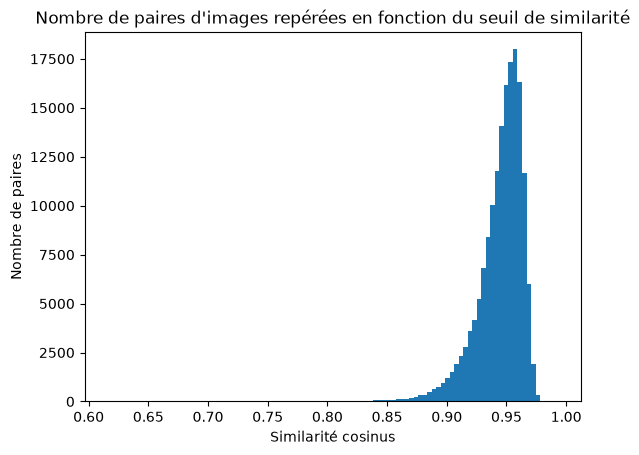

In [36]:
plt.hist(sim, bins=100)
plt.xlabel("Similarité cosinus")
plt.ylabel("Nombre de paires")

plt.title("Nombre de paires d'images repérées en fonction du seuil de similarité")

plt.show()

In [32]:
nb_images = indices.shape[0]
print(nb_images)

indice_img=[]
indice_voisin=[]
chemin_image=[]
chemin_voisin=[]
liste_similarites=[]

for image in np.arange(nb_images):
    for voisin, similarite in zip(indices[image][1:], similarites[image][1:]):
        if similarite >= 0.98:
            indice_img.append(image)
            indice_voisin.append(voisin)
            chemin_image.append(img_chemin[image])
            chemin_voisin.append(img_chemin[voisin])
            liste_similarites.append(similarite)
            print (f"Chemin de l'image originelle {img_chemin[image]}")
            print (f"Chemin de l'image voisine {img_chemin[voisin]}")
            print(f"similarite {similarite}")



20835
Chemin de l'image originelle /Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1169.png
Chemin de l'image voisine /Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1532.png
similarite 0.9816986322402954
Chemin de l'image originelle /Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1221.png
Chemin de l'image voisine /Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1538.png
similarite 0.9865094423294067
Chemin de l'image originelle /Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-130.png
Chemin de l'image voisine /Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1538.png
similarite 0.9865094423294067
Chemin de l'image originelle /Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1360.png
Chemin de l'image voisine /Users/antoine/Desktop/Liora/Projet/COVID

In [33]:
print(len(indice_img))
print(len(indice_voisin))

print(indice_img)
print(indice_voisin)

24
24
[np.int64(178), np.int64(234), np.int64(309), np.int64(362), np.int64(362), np.int64(518), np.int64(525), np.int64(525), np.int64(550), np.int64(554), np.int64(1030), np.int64(1096), np.int64(2754), np.int64(2833), np.int64(2840), np.int64(2899), np.int64(3010), np.int64(3010), np.int64(3014), np.int64(3017), np.int64(14522), np.int64(16260), np.int64(18937), np.int64(19392)]
[np.int64(512), np.int64(518), np.int64(518), np.int64(316), np.int64(699), np.int64(234), np.int64(3014), np.int64(554), np.int64(3017), np.int64(3014), np.int64(2899), np.int64(2899), np.int64(2833), np.int64(2754), np.int64(2833), np.int64(1096), np.int64(550), np.int64(522), np.int64(525), np.int64(550), np.int64(16260), np.int64(19392), np.int64(11656), np.int64(16260)]


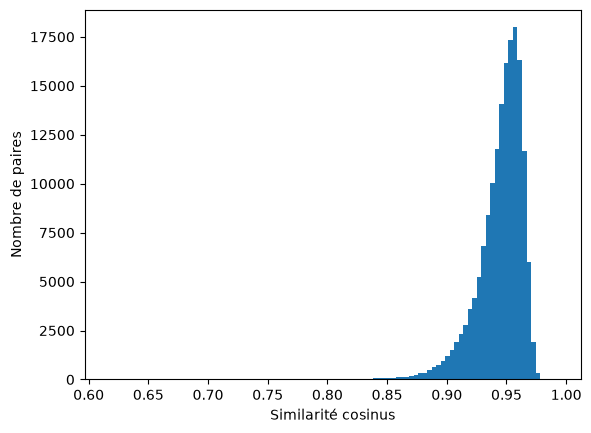

In [29]:
plt.hist(sim, bins=100)
plt.xlabel("Similarité cosinus")
plt.ylabel("Nombre de paires")
plt.show()

652
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1169.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1532.png


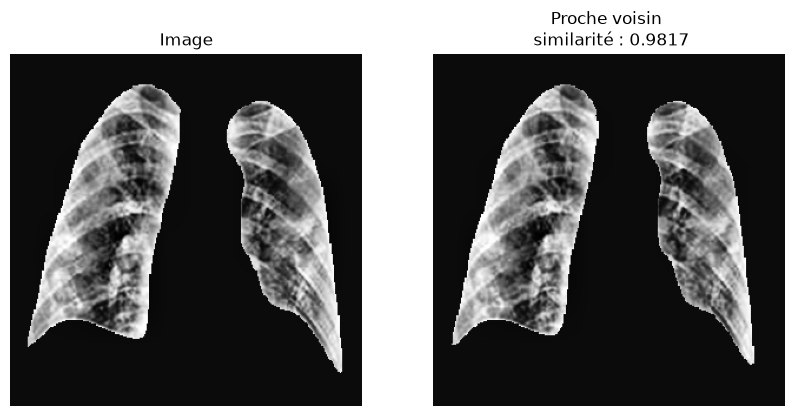

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1221.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1538.png


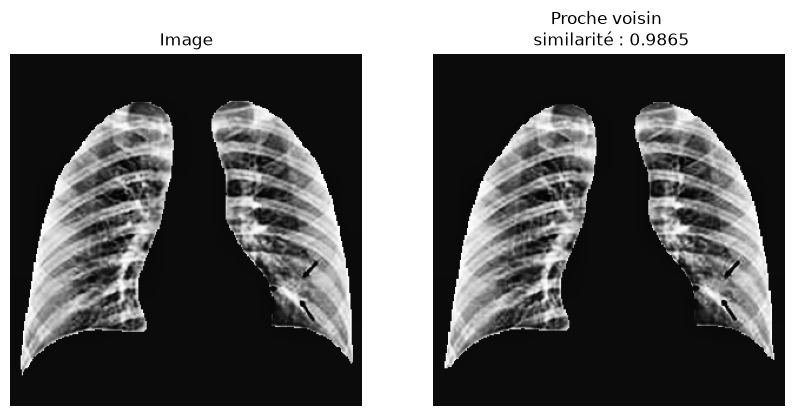

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-130.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1538.png


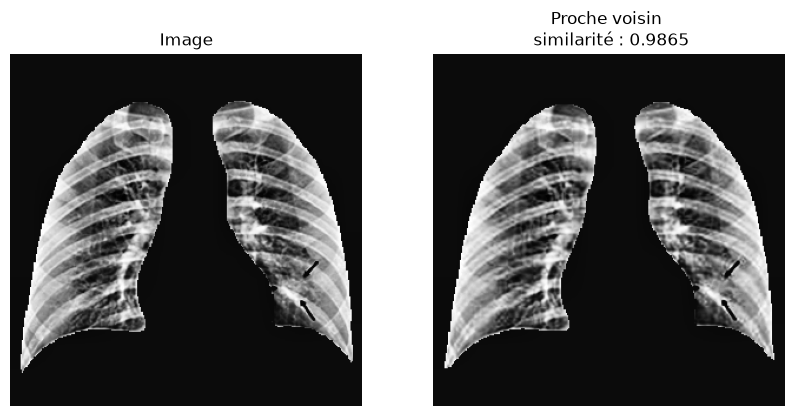

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1360.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1306.png


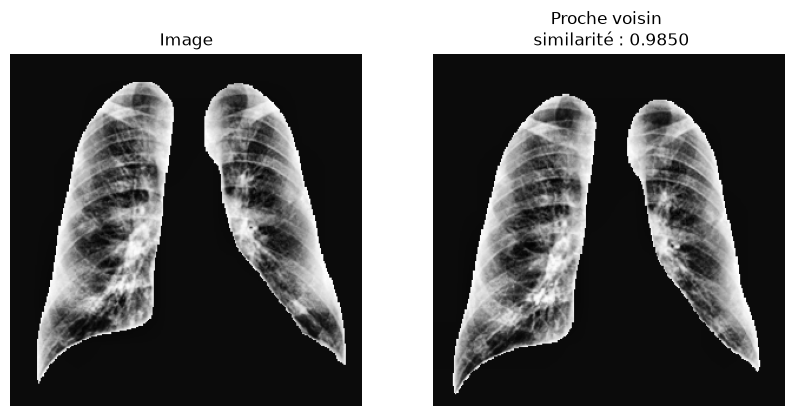

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1360.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1706.png


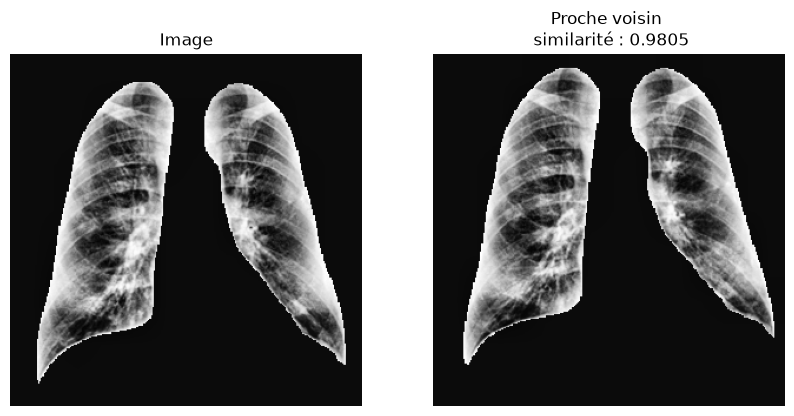

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1538.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1221.png


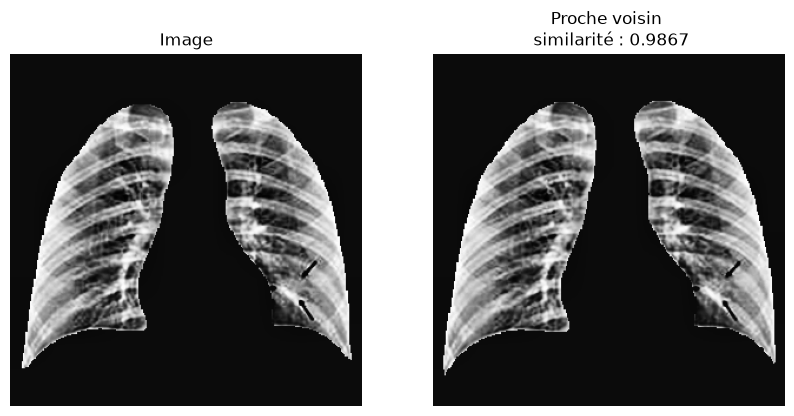

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1544.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-652.png


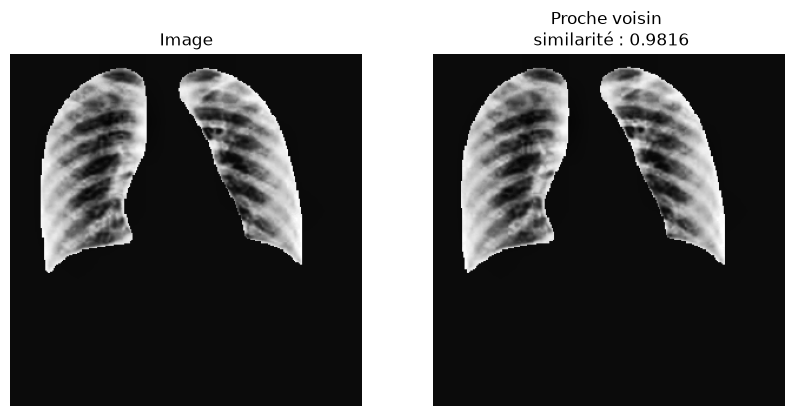

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1544.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1571.png


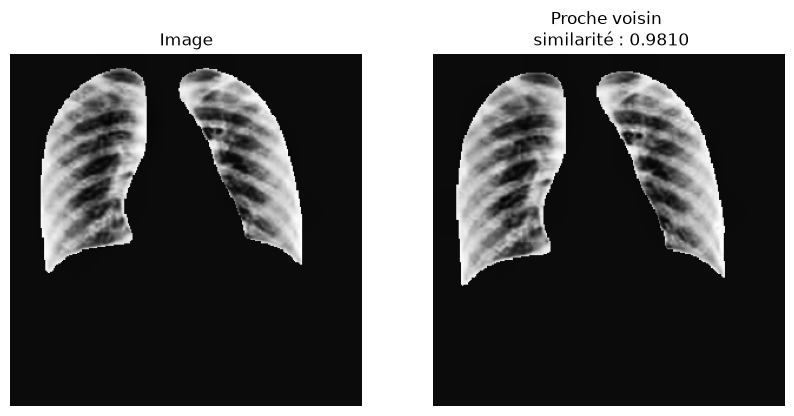

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1568.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-655.png


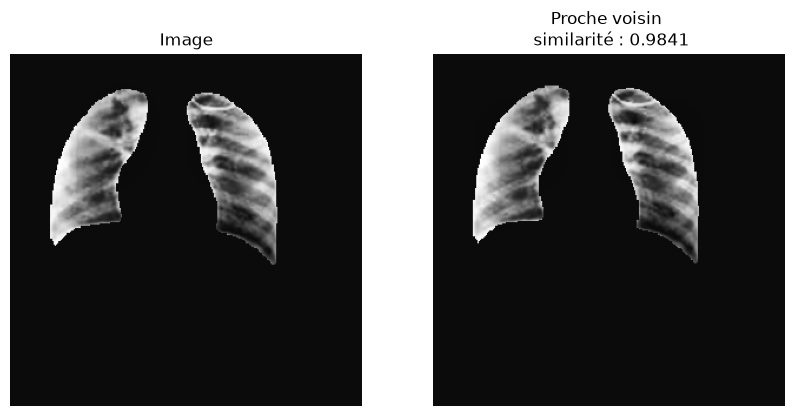

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1571.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-652.png


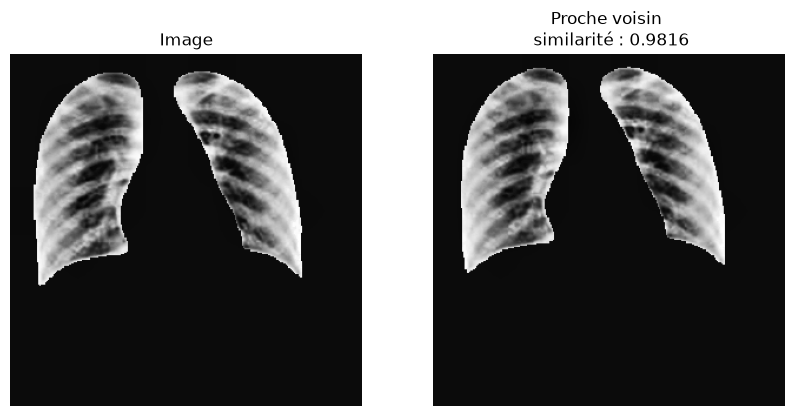

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-201.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-527.png


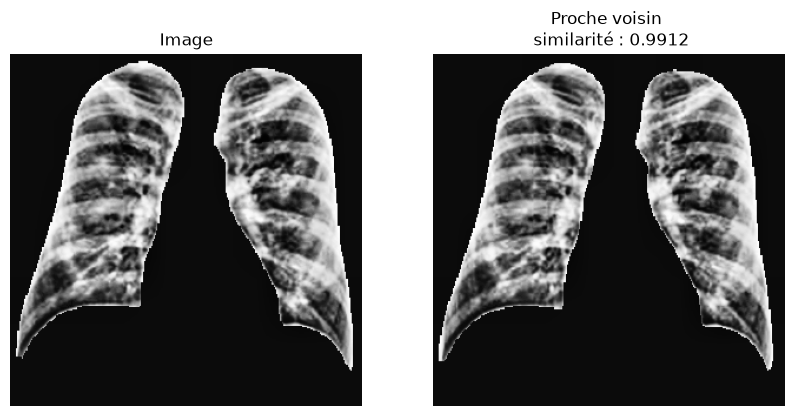

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-207.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-527.png


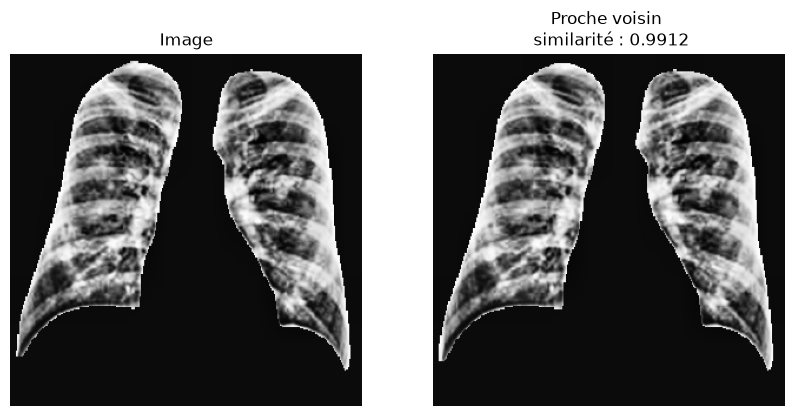

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-379.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-454.png


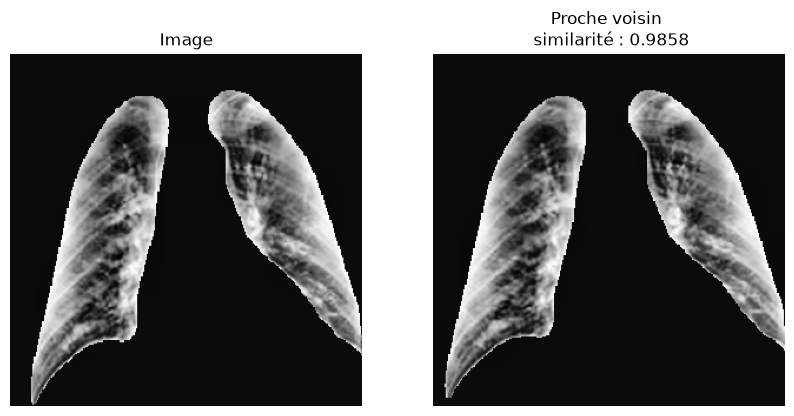

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-454.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-379.png


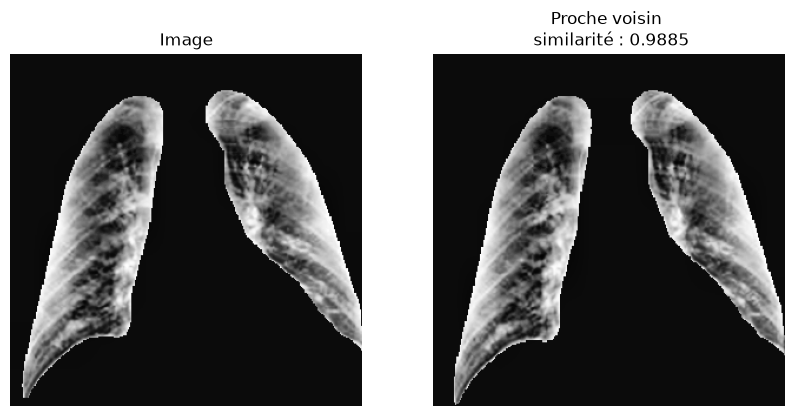

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-460.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-454.png


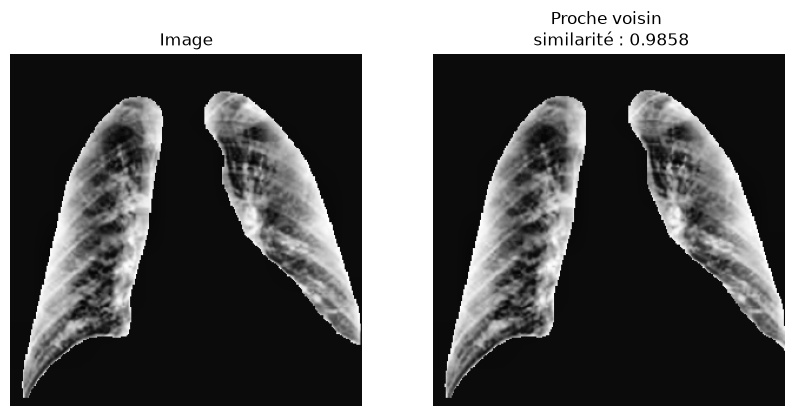

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-527.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-207.png


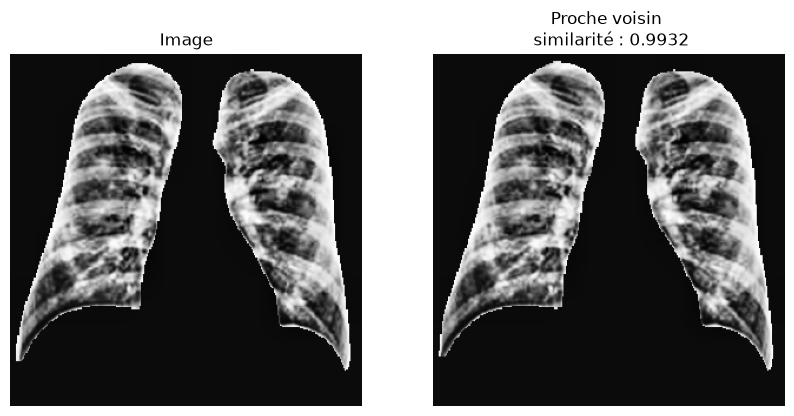

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-649.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1568.png


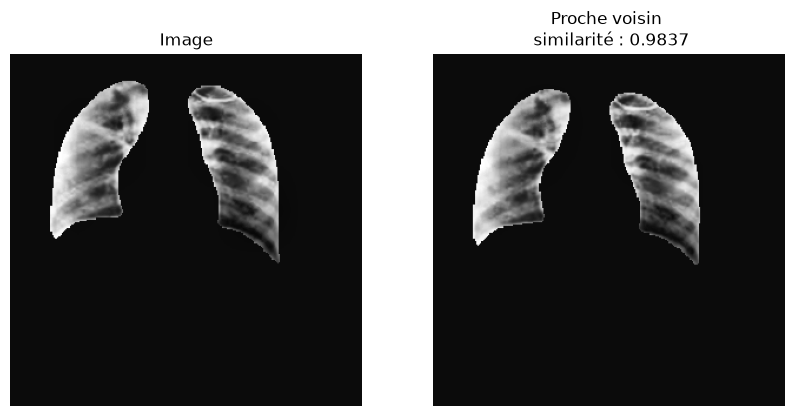

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-649.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1541.png


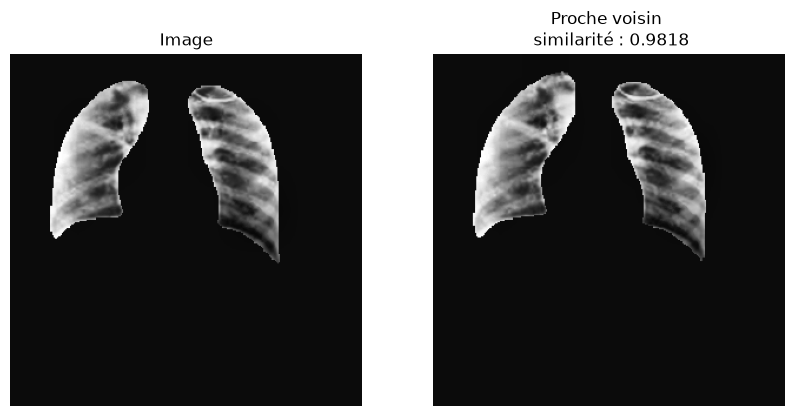

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-652.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1544.png


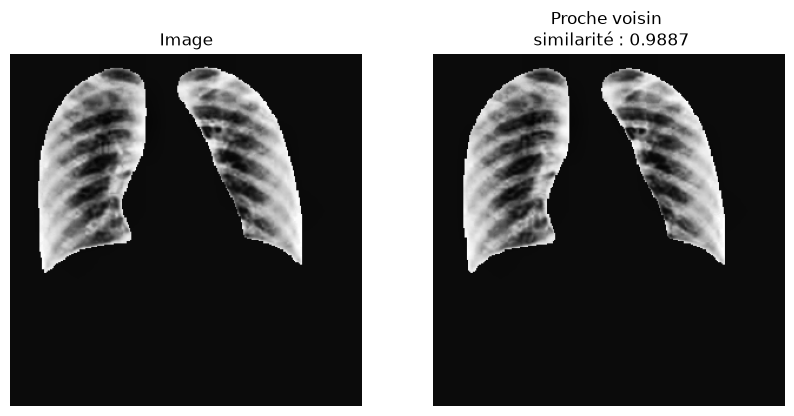

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-655.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/COVID/COVID-1568.png


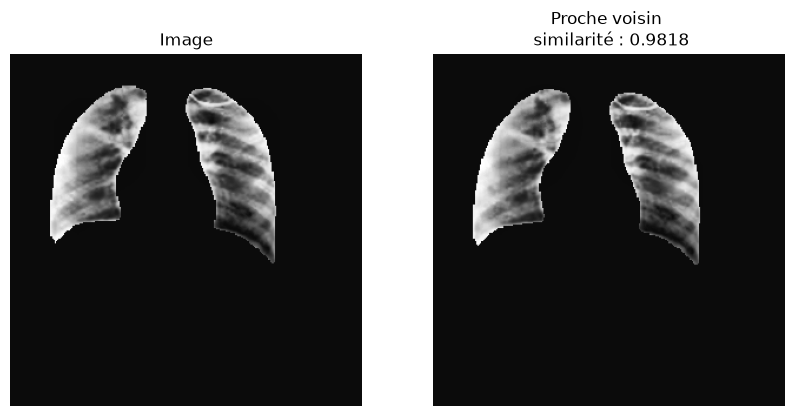

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/Normal/Normal-5498.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/Normal/Normal-7066.png


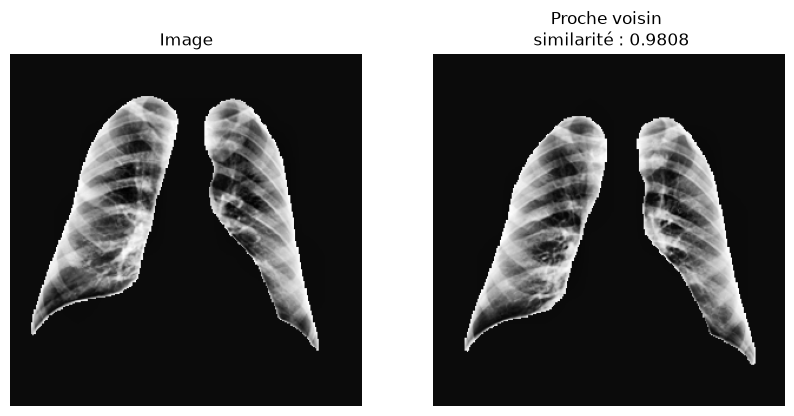

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/Normal/Normal-7066.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/Normal/Normal-9903.png


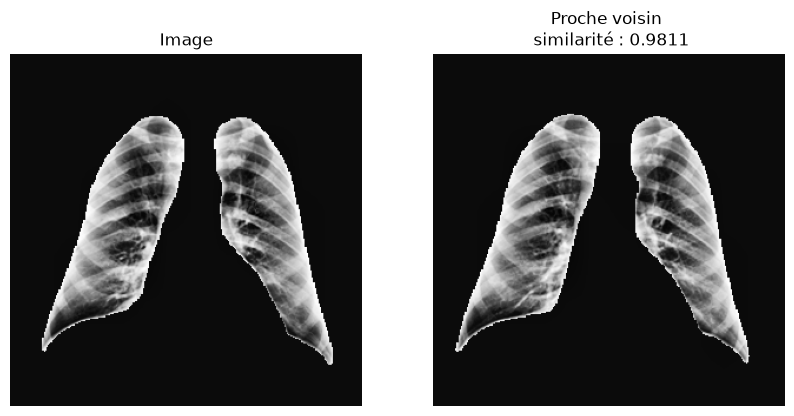

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/Normal/Normal-9494.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/Normal/Normal-2899.png


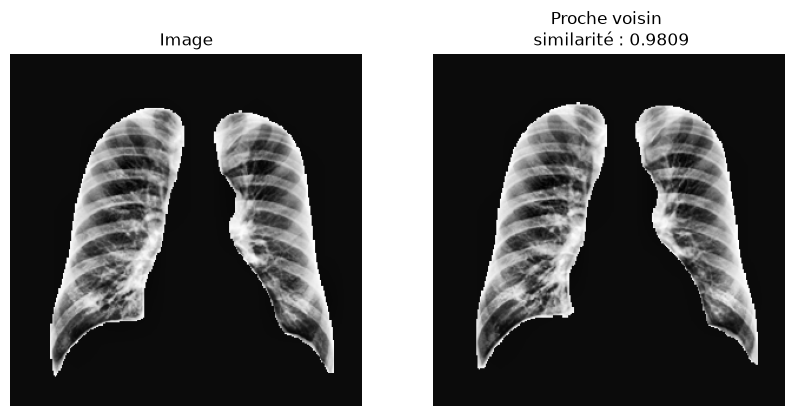

/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/Normal/Normal-9903.png
/Users/antoine/Desktop/Liora/Projet/COVID-19_Radiography_Dataset_CLAHE/Normal/Normal-7066.png


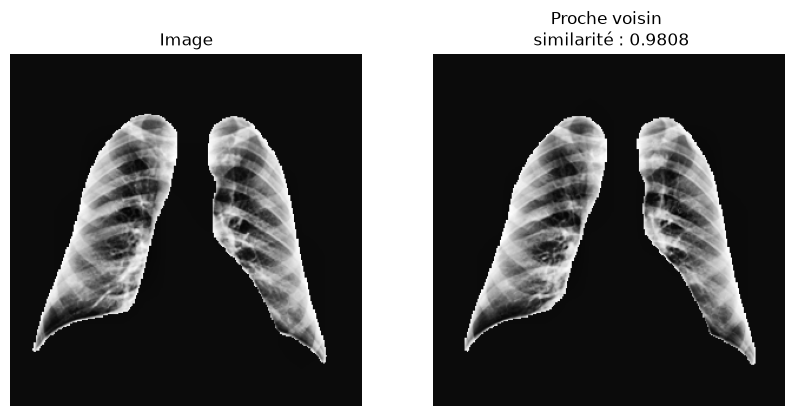

In [51]:
print(len(dataset))

for index, images in enumerate (chemin_image):
    print(chemin_image[index])
    image_path=chemin_image[index]
    img=cv2.imread(image_path)

    print(chemin_voisin[index])
    voisin_path=chemin_voisin[index]
    vsn=cv2.imread(voisin_path)

    fig=plt.figure(figsize=(10,10))

    plt.subplot(1,2, 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow((vsn))
    plt.title(f"Proche voisin \n similarité : {liste_similarites[index]:.4f}")
    plt.axis("off")

    plt.show()